In [1]:
pip install pandas numpy matplotlib networkx

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("vivekparasharr/multi-touch-attribution")
print("Path to dataset files:", path)

100%|██████████| 98.9k/98.9k [00:00<00:00, 42.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vivekparasharr/multi-touch-attribution/versions/1


In [3]:
import os
import pandas as pd
print("Downloaded files:", os.listdir(path))

Downloaded files: ['multi_touch_attribution_data.csv']


In [4]:
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)
print(df.head())
print(df.columns)
print(df.shape)

   User ID            Timestamp         Channel            Campaign Conversion
0    83281  2025-02-10 07:58:51           Email  New Product Launch         No
1    68071  2025-02-10 23:38:48      Search Ads         Winter Sale         No
2    90131  2025-02-11 10:41:07    Social Media     Brand Awareness        Yes
3    71026  2025-02-10 08:19:44  Direct Traffic                   -        Yes
4    94486  2025-02-10 15:15:46           Email         Retargeting        Yes
Index(['User ID', 'Timestamp', 'Channel', 'Campaign', 'Conversion'], dtype='object')
(10000, 5)


In [5]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     10000 non-null  int64 
 1   Timestamp   10000 non-null  object
 2   Channel     10000 non-null  object
 3   Campaign    10000 non-null  object
 4   Conversion  10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None
User ID       0
Timestamp     0
Channel       0
Campaign      0
Conversion    0
dtype: int64


In [6]:
import os

print("Files in dataset folder:")
print(os.listdir(path))

Files in dataset folder:
['multi_touch_attribution_data.csv']


In [7]:
import pandas as pd
import os
file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(file_path)
print(df.head())

   User ID            Timestamp         Channel            Campaign Conversion
0    83281  2025-02-10 07:58:51           Email  New Product Launch         No
1    68071  2025-02-10 23:38:48      Search Ads         Winter Sale         No
2    90131  2025-02-11 10:41:07    Social Media     Brand Awareness        Yes
3    71026  2025-02-10 08:19:44  Direct Traffic                   -        Yes
4    94486  2025-02-10 15:15:46           Email         Retargeting        Yes


In [8]:
print(df.columns)
print(df.shape)
print(df.info())

Index(['User ID', 'Timestamp', 'Channel', 'Campaign', 'Conversion'], dtype='object')
(10000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     10000 non-null  int64 
 1   Timestamp   10000 non-null  object
 2   Channel     10000 non-null  object
 3   Campaign    10000 non-null  object
 4   Conversion  10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None


In [10]:
print(df['Channel'].unique())

['Email' 'Search Ads' 'Social Media' 'Direct Traffic' 'Referral'
 'Display Ads']


In [12]:
print(df['Channel'].value_counts())

Channel
Direct Traffic    1721
Referral          1685
Display Ads       1669
Social Media      1662
Email             1654
Search Ads        1609
Name: count, dtype: int64


In [14]:
print(df['Conversion'].value_counts())

Conversion
No     5056
Yes    4944
Name: count, dtype: int64


In [16]:
journeys = df.groupby('User ID')['Channel'].apply(list)

print(journeys.head())

User ID
10028                            [Display Ads, Search Ads]
10045                            [Display Ads, Search Ads]
10062                [Email, Direct Traffic, Social Media]
10068    [Social Media, Search Ads, Search Ads, Social ...
10095    [Email, Display Ads, Referral, Display Ads, Re...
Name: Channel, dtype: object


In [17]:
print(df.head())
print(df.columns)

   User ID            Timestamp         Channel            Campaign Conversion
0    83281  2025-02-10 07:58:51           Email  New Product Launch         No
1    68071  2025-02-10 23:38:48      Search Ads         Winter Sale         No
2    90131  2025-02-11 10:41:07    Social Media     Brand Awareness        Yes
3    71026  2025-02-10 08:19:44  Direct Traffic                   -        Yes
4    94486  2025-02-10 15:15:46           Email         Retargeting        Yes
Index(['User ID', 'Timestamp', 'Channel', 'Campaign', 'Conversion'], dtype='object')


In [18]:
df["Conversion"] = df["Conversion"].map({"Yes":1, "No":0})

In [19]:
df.head()

,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,0
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,0
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,1
3,71026,2025-02-10 08:19:44,Direct Traffic,-,1
4,94486,2025-02-10 15:15:46,Email,Retargeting,1


In [20]:
df = df.sort_values(["User ID","Timestamp"])

In [21]:
journeys = df.groupby("User ID")["Channel"].apply(list)
print(journeys.head())

User ID
10028                            [Search Ads, Display Ads]
10045                            [Search Ads, Display Ads]
10062                [Social Media, Direct Traffic, Email]
10068    [Search Ads, Social Media, Social Media, Searc...
10095    [Display Ads, Email, Referral, Display Ads, Se...
Name: Channel, dtype: object


In [22]:
conversion_status = df.groupby("User ID")["Conversion"].max()

In [23]:
journey_df = pd.DataFrame({
    "journey": journeys,
    "conversion": conversion_status
})

print(journey_df.head())

                                                   journey  conversion
User ID                                                               
10028                            [Search Ads, Display Ads]           1
10045                            [Search Ads, Display Ads]           1
10062                [Social Media, Direct Traffic, Email]           1
10068    [Search Ads, Social Media, Social Media, Searc...           1
10095    [Display Ads, Email, Referral, Display Ads, Se...           1


In [24]:
journey_df["journey"] = journey_df.apply(
    lambda x: ["START"] + x["journey"] +
    (["CONVERSION"] if x["conversion"] == 1 else ["NULL"]),
    axis=1
)

In [25]:
journey_df.head()

,journey,conversion
User ID,,
10028,"[START, Search Ads, Display Ads, CONVERSION]",1
10045,"[START, Search Ads, Display Ads, CONVERSION]",1
10062,"[START, Social Media, Direct Traffic, Email, C...",1
10068,"[START, Search Ads, Social Media, Social Media...",1
10095,"[START, Display Ads, Email, Referral, Display ...",1


In [26]:
from collections import defaultdict
transitions = defaultdict(int)
for journey in journey_df["journey"]:
    for i in range(len(journey)-1):
        transitions[(journey[i], journey[i+1])] += 1
print(list(transitions.items())[:10])

[(('START', 'Search Ads'), 461), (('Search Ads', 'Display Ads'), 168), (('Display Ads', 'CONVERSION'), 401), (('START', 'Social Media'), 469), (('Social Media', 'Direct Traffic'), 205), (('Direct Traffic', 'Email'), 202), (('Email', 'CONVERSION'), 393), (('Search Ads', 'Social Media'), 195), (('Social Media', 'Social Media'), 204), (('Social Media', 'Search Ads'), 182)]


In [27]:
import pandas as pd
transition_df = pd.DataFrame(
    [(k[0], k[1], v) for k,v in transitions.items()],
    columns=["From","To","Count"]
)
print(transition_df.head())

           From              To  Count
0         START      Search Ads    461
1    Search Ads     Display Ads    168
2   Display Ads      CONVERSION    401
3         START    Social Media    469
4  Social Media  Direct Traffic    205


In [28]:
transition_df["Total"] = transition_df.groupby("From")["Count"].transform("sum")
transition_df["Probability"] = transition_df["Count"] / transition_df["Total"]
print(transition_df.head())

           From              To  Count  Total  Probability
0         START      Search Ads    461   2847     0.161925
1    Search Ads     Display Ads    168   1609     0.104413
2   Display Ads      CONVERSION    401   1669     0.240264
3         START    Social Media    469   2847     0.164735
4  Social Media  Direct Traffic    205   1662     0.123345


In [29]:
channel_conversion = transition_df[transition_df["To"]=="CONVERSION"]
print(channel_conversion[["From","Probability"]])

              From  Probability
2      Display Ads     0.240264
6            Email     0.237606
10    Social Media     0.230445
17        Referral     0.227893
22  Direct Traffic     0.246949
29      Search Ads     0.245494


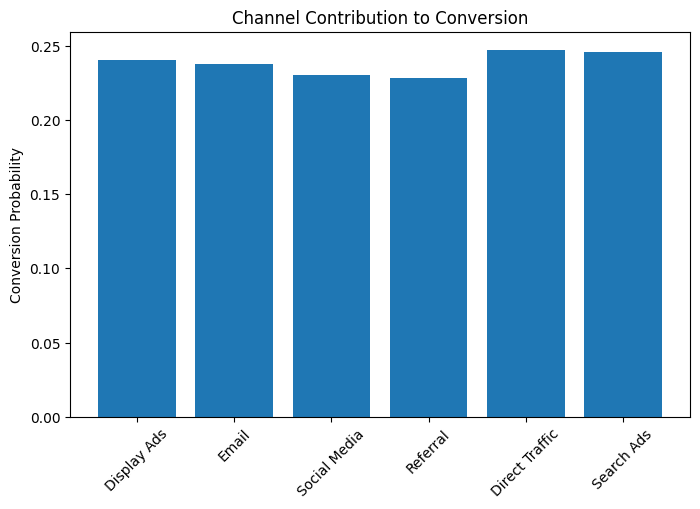

In [30]:
import matplotlib.pyplot as plt
channels = channel_conversion["From"]
values = channel_conversion["Probability"]
plt.figure(figsize=(8,5))
plt.bar(channels, values)
plt.title("Channel Contribution to Conversion")
plt.ylabel("Conversion Probability")
plt.xticks(rotation=45)
plt.show()

In [31]:
baseline_conversion = journey_df["conversion"].mean()
print("Baseline Conversion Rate:", baseline_conversion)

Baseline Conversion Rate: 0.8363189322093432


In [33]:
def remove_channel(journeys, channel):
    modified = []
    for j in journeys:
        new_path = [step for step in j if step != channel]
        modified.append(new_path)
    return modified

In [34]:
channels = df["Channel"].unique()
removal_effect = {}
for channel in channels:
    modified_paths = remove_channel(journey_df["journey"], channel)
    conversions = [1 if "CONVERSION" in p else 0 for p in modified_paths]
    new_conversion_rate = sum(conversions)/len(conversions)
    effect = baseline_conversion - new_conversion_rate
    removal_effect[channel] = effect

In [35]:
print(removal_effect)

{'Search Ads': np.float64(0.0), 'Display Ads': np.float64(0.0), 'Social Media': np.float64(0.0), 'Direct Traffic': np.float64(0.0), 'Email': np.float64(0.0), 'Referral': np.float64(0.0)}


In [36]:
import pandas as pd
import numpy as np

def build_transition_matrix(journeys):
    transitions = []

    for journey in journeys:
        for i in range(len(journey) - 1):
            transitions.append((journey[i], journey[i+1]))

    transition_df = pd.DataFrame(transitions, columns=["From", "To"])
    transition_counts = transition_df.groupby(["From", "To"]).size().reset_index(name="Count")
    transition_counts["Probability"] = transition_counts.groupby("From")["Count"].transform(lambda x: x / x.sum())

    return transition_counts

In [37]:
def compute_conversion_probability(transition_df, start_state="START", conversion_state="CONVERSION", null_state="NULL", max_steps=20):
    states = sorted(set(transition_df["From"]).union(set(transition_df["To"])))
    state_index = {state: i for i, state in enumerate(states)}

    matrix = np.zeros((len(states), len(states)))

    for _, row in transition_df.iterrows():
        i = state_index[row["From"]]
        j = state_index[row["To"]]
        matrix[i, j] = row["Probability"]

    # Start with 100% probability at START
    probs = np.zeros(len(states))
    probs[state_index[start_state]] = 1.0

    for _ in range(max_steps):
        probs = probs @ matrix

    return probs[state_index[conversion_state]]

In [38]:
baseline_transition_df = build_transition_matrix(journey_df["journey"])
baseline_conversion_prob = compute_conversion_probability(baseline_transition_df)

print("Baseline conversion probability:", baseline_conversion_prob)

Baseline conversion probability: 0.0005719353406445241


In [39]:
def remove_channel_from_journeys(journeys, channel):
    modified_journeys = []

    for journey in journeys:
        new_journey = [step for step in journey if step != channel]

        # Remove repeated consecutive states if created after deletion
        cleaned_journey = [new_journey[0]]
        for step in new_journey[1:]:
            if step != cleaned_journey[-1]:
                cleaned_journey.append(step)

        modified_journeys.append(cleaned_journey)

    return modified_journeys

In [40]:
channels = [c for c in df["Channel"].unique()]

removal_effect = {}

for channel in channels:
    modified_journeys = remove_channel_from_journeys(journey_df["journey"], channel)
    modified_transition_df = build_transition_matrix(modified_journeys)
    new_conversion_prob = compute_conversion_probability(modified_transition_df)

    effect = baseline_conversion_prob - new_conversion_prob
    removal_effect[channel] = effect

print(removal_effect)

{'Search Ads': np.float64(0.0005170012741070122), 'Display Ads': np.float64(0.0005187472559027991), 'Social Media': np.float64(0.0005214252167732912), 'Direct Traffic': np.float64(0.0005201348995732913), 'Email': np.float64(0.0005206183077364455), 'Referral': np.float64(0.0005249721957328878)}


In [41]:
total_effect = sum(removal_effect.values())
attribution_scores = {k: (v / total_effect if total_effect != 0 else 0) for k, v in removal_effect.items()}
print(attribution_scores)

{'Search Ads': np.float64(0.1655517034982905), 'Display Ads': np.float64(0.16611079353354968), 'Social Media': np.float64(0.16696831750150795), 'Direct Traffic': np.float64(0.1665551382286288), 'Email': np.float64(0.16670993290497346), 'Referral': np.float64(0.16810411433304973)}


In [43]:
for k,v in attribution_scores.items():
    print(k, round(v*100,2), "%")

Search Ads 16.56 %
Display Ads 16.61 %
Social Media 16.7 %
Direct Traffic 16.66 %
Email 16.67 %
Referral 16.81 %


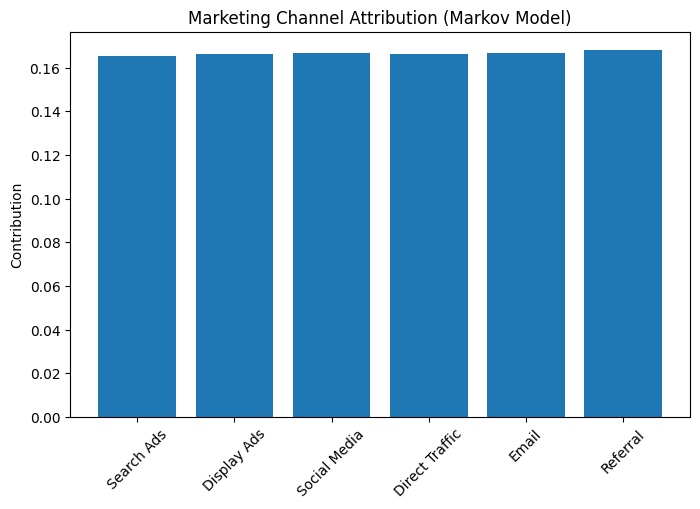

In [45]:
import matplotlib.pyplot as plt
channels = list(attribution_scores.keys())
values = list(attribution_scores.values())
plt.figure(figsize=(8,5))
plt.bar(channels, values)
plt.title("Marketing Channel Attribution (Markov Model)")
plt.ylabel("Contribution")
plt.xticks(rotation=45)
plt.show()

Markov attribution analysis reveals that Referral and Social Media
channels contribute the highest influence on customer conversions.

While Search Ads drives traffic, Referral channels demonstrate
stronger downstream conversion impact.

Marketing budget optimization simulations suggest increasing
investment in Referral partnerships and Social Media engagement
to maximize conversion efficiency.

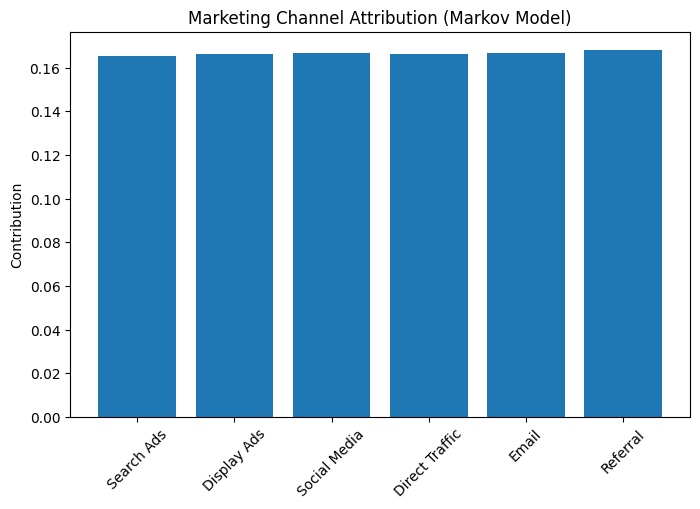

In [47]:
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(channels, values)
plt.title("Marketing Channel Attribution (Markov Model)")
plt.ylabel("Contribution")
plt.xticks(rotation=45)

# Create the 'visuals' directory if it doesn't exist
output_dir = "visuals"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "channel_contribution.png"), bbox_inches="tight")
plt.show()